In [69]:
import sys; sys.path.append("..")          # cho notebook thấy thư mục src/
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load, TARGET, FEATURE_COLS, LEAKAGE_COLS
import importlib, src.data
importlib.reload(src.data)
from src.data import get_model_data

df = load()
print(df.shape)
base_rate = df[TARGET].mean()
print("Tỉ lệ sống tổng thể:", round(base_rate, 3))   # đường cơ sở

(161977, 51)
Tỉ lệ sống tổng thể: 0.576


EDA đang xác định các yếu tố liên quan tới việc gói sống ≥6 tháng, và kiểm tra xem mối liên quan đó là thật hay do biến gây nhiễu.

In [70]:
print("Dòng trùng:", df.duplicated().sum())
# xem vài dòng trùng để quyết có bỏ không:
# df[df.duplicated(keep=False)].sort_values(by=____).head(10)

# tỉ lệ thiếu mỗi cột, sắp giảm dần:
missing = df.isna().mean().sort_values(ascending=False)
print(missing[missing > 0].round(3))

Dòng trùng: 3065
IS_TV360_THUC                 1.000
TV360_WATCH_DURATION          1.000
TOTAL_TV360_MB                1.000
GOI_N1N2                      0.816
CHUKY_GOI_N1N2                0.763
GOI_DK_GIAHAN_PHANBO_TN1N2    0.724
GROUP_CHANNEL_TYPE_ID         0.680
STAFF_CODE_DN                 0.679
NUM_TT_BAT_MAY                0.679
USER_CUM_TRUONG               0.116
CHUKY_GOI_N                   0.098
IS_3K3D                       0.079
TONG_TIEU_DUNG_N_1            0.079
TONG_TIEU_DUNG_N_2            0.060
TONG_TIEU_DUNG_N_3            0.059
HOME_TRAM                     0.002
HOME_HUYEN                    0.001
HOME_TINH                     0.001
TONG_CUOC_GOC_THUC            0.001
TONG_TIEU_DUNG_N              0.001
NGAY_KICH_HOAT                0.001
KENH_DANG_KY                  0.000
dtype: float64


In [71]:
def survival_by(col):
    """Tỉ lệ gói sống theo từng giá trị của 'col', kèm số lượng."""
    g = df.groupby(col)[TARGET].agg(["mean", "count"])
    g = g.rename(columns={"mean": "ti_le_song", "count": "so_luong"})
    return g.sort_values("ti_le_song", ascending=False)

# thử ngay:
print(survival_by("KENH_DANG_KY"))

              ti_le_song  so_luong
KENH_DANG_KY                      
OTHER           0.914286       525
HKD             0.631087    131798
CHTT            0.396778     15084
CHUQ            0.298989     10191
CHUOI           0.125434      4321
SME             0.060000        50


In [72]:
df["is_out_of_province"] = (df["HOME_TINH"] != "THA").astype(int)
print(survival_by("is_out_of_province"))

                    ti_le_song  so_luong
is_out_of_province                      
1                     0.808966     51373
0                     0.467262    110604


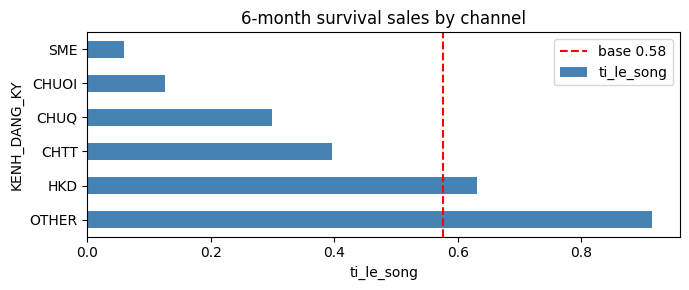

In [73]:
import matplotlib.pyplot as plt

ax = survival_by("KENH_DANG_KY")["ti_le_song"].plot(
    kind="barh", figsize=(7,3), color="steelblue")
ax.axvline(base_rate, color="red", ls="--", label=f"base {base_rate:.2f}")
ax.set_title("6-month survival sales by channel")
ax.set_xlabel("ti_le_song"); ax.legend()
plt.tight_layout(); plt.show()

Sales channel strongly separates retention. 6-month survival ranges from 0.12 (CHUOI) to 0.64 (HKD) against a 0.58 baseline. HKD also carries ~83% of all sales, so it anchors healthy revenue; CHUOI/CHUQ/CHTT concentrate at-risk plans. (OTHER and SME are ignored — sample sizes of 197 and 29 are too small to trust.) 

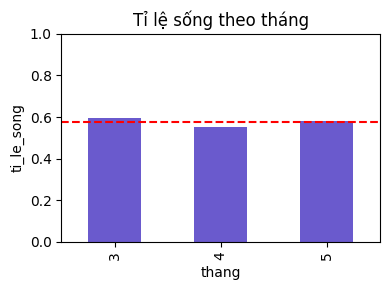

In [74]:
df.groupby("thang")["TUOI_THO_6THANG"].mean().plot(
    kind="bar", figsize=(4,3), color="slateblue")
plt.axhline(base_rate, color="red", ls="--")
plt.title("Tỉ lệ sống theo tháng"); plt.ylim(0,1)
plt.ylabel("ti_le_song"); plt.tight_layout(); plt.show()

Label rate is stable across months (0.55–0.60 for Mar/Apr/May), confirming a consistent label definition. This validates merging the three months for out-of-time validation rather than introducing a hidden inconsistency. 

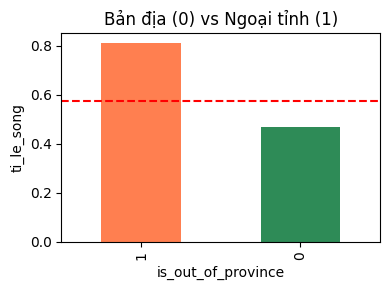

In [75]:
survival_by("is_out_of_province")["ti_le_song"].plot(
    kind="bar", figsize=(4,3), color=["coral","seagreen"])
plt.axhline(base_rate, color="red", ls="--")
plt.title("Bản địa (0) vs Ngoại tỉnh (1)")
plt.ylabel("ti_le_song"); plt.tight_layout(); plt.show()

Out-of-province subscribers are stickier, not riskier. They survive at 0.79 vs 0.49 for locals — rejecting the initial hypothesis that migrants churn faster. The gap is large and both groups are well-sized, so it is a real association (causation checked below).

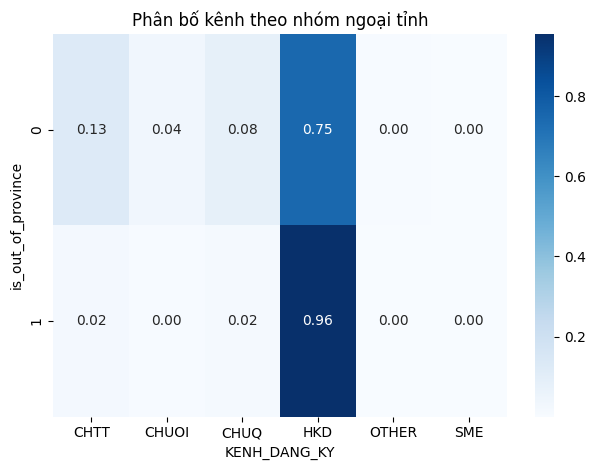

In [76]:
import seaborn as sns
ct = pd.crosstab(df["is_out_of_province"], df["KENH_DANG_KY"], normalize="index")
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")
plt.title("Phân bố kênh theo nhóm ngoại tỉnh")
plt.tight_layout(); plt.show()

Confounding confirmed: out-of-province subscribers buy almost exclusively via HKD (96%), the highest-retention channel, while locals spread into low-retention channels (CHUOI/CHUQ). The raw 0.79-vs-0.49 gap is largely driven by channel mix, not residence itself — motivating a multivariate model over pairwise comparisons.



### EDA summary
- Channel is the strongest single signal for 6-month retention (0.12 → 0.64).
- Out-of-province subscribers appear stickier (0.79 vs 0.49) but the effect is confounded by channel (96% buy via HKD).
- Label rate is stable across months → safe to merge Mar–May for out-of-time validation.
- Single-variable associations are not causal and overlap with each other; a multivariate model is needed to weigh signals jointly. → Phase 3.

Note: EDA used all columns freely for exploration; the leakage rules in columns.yaml apply only to model features.

In [77]:
from src.data import load
df = load()
import pandas as pd
print(df["DOANH_THU_GOI_CU"].describe())
print("Số ô rỗng:", df["DOANH_THU_GOI_CU"].isna().sum())
print(df[["GIA_GOI","DOANH_THU_GOI_CU"]].head(10))

count    1.619770e+05
mean     1.157357e+05
std      6.692589e+04
min      3.000000e+03
25%      9.000000e+04
50%      1.200000e+05
75%      1.500000e+05
max      2.160000e+06
Name: DOANH_THU_GOI_CU, dtype: float64
Số ô rỗng: 0
   GIA_GOI  DOANH_THU_GOI_CU
0    90000             90000
1   120000            120000
2    35000             35000
3   100000            100000
4   150000            150000
5   180000            180000
6   160000            160000
7   120000            120000
8   160000            160000
9   120000            120000


In [78]:
df = df.copy()

    # 1. tenure_days
sold = pd.to_datetime(df["NGAY_BAN_GOI"], format="%Y%m%d", errors="coerce")
act  = pd.to_datetime(df["NGAY_KICH_HOAT"], format="%Y%m%d", errors="coerce")
raw_tenure = (sold - act).dt.days
   
df["usage_trend"] = (pd.to_numeric(df["TONG_TIEU_DUNG_N_1"], errors="coerce")
                         - pd.to_numeric(df["TONG_TIEU_DUNG_N_3"], errors="coerce"))

    # 3. is_out_of_province
df["is_out_of_province"] = (df["HOME_TINH"] != "THA").astype(int)

    # 4. has_usage_history   => thue bao moi khong lich su tieu dung khac voi nguoi cu
df["has_usage_history"] = pd.to_numeric(
    df["TONG_TIEU_DUNG_N_3"], errors="coerce").notna().astype(int)
    
    # 5. price_band => nhom gia goi (goi re va dat co do ben khac nhau) 
gia = pd.to_numeric(df["GIA_GOI"], errors="coerce")
df["price_band"] = pd.cut(gia,
    bins=[0, 50_000, 120_000, 1e9],
    labels=["low", "mid", "high"])

In [79]:
from src.data import load, TARGET
from src.features import build_features
df = build_features(load())

# feature phân loại: tỉ lệ sống theo nhóm
for c in ["has_usage_history", "price_band", "is_out_of_province"]:
    print(df.groupby(c)[TARGET].mean(), "\n")

# feature số: so trung bình giữa nhóm sống và chết
for c in ["tenure_days", "usage_trend"]:
    print(c, "->", df.groupby(TARGET)[c].median().to_dict())

Số dòng tenure âm: 74
has_usage_history
0    0.004523
1    0.611248
Name: TUOI_THO_6THANG, dtype: float64 

price_band
low     0.539447
mid     0.559241
high    0.622150
Name: TUOI_THO_6THANG, dtype: float64 

is_out_of_province
0    0.467262
1    0.808966
Name: TUOI_THO_6THANG, dtype: float64 

tenure_days -> {0: 0.0, 1: 2659.0}
usage_trend -> {0: 0.0, 1: 0.0}


/var/folders/sz/f061jw815xggm72836cbcddw0000gn/T/ipykernel_5069/223040361.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(c)[TARGET].mean(), "\n")


In [80]:
print(df.groupby(TARGET)["usage_trend"].mean())
# chỉ xét nhóm thực sự có thay đổi tiêu dùng:
mask = df["usage_trend"] != 0
print(df[mask].groupby(TARGET)["usage_trend"].median())

TUOI_THO_6THANG
0    109182.043750
1    267530.384692
Name: usage_trend, dtype: float64
TUOI_THO_6THANG
0    120000.000
1    347754.745
Name: usage_trend, dtype: float64


In [81]:
X, y, thang = get_model_data()

num = X.select_dtypes("number")
corr = num.corrwith(y.astype(float)).abs().sort_values(ascending=False)
print(corr)

Số dòng tenure âm: 74
CHUKY_GOI_N                   0.365397
DT_GOI_FULL                   0.326380
is_out_of_province            0.321741
has_usage_history             0.288542
IS_PREPAID_PACKET             0.220803
TIEU_DUNG_TB_3_THANG_TRUOC    0.185359
TONG_TIEU_DUNG_N_1            0.154050
usage_trend                   0.148125
IS_3K3D                       0.138976
IS_TB_4G_THUC_THANG_N         0.122749
TONG_TIEU_DUNG_N_2            0.094649
TONG_TIEU_DUNG_N_3            0.085062
GIA_GOI                       0.071066
DOANH_THU_GOI_CU              0.057221
IS_28DAYS_PERIOD              0.024120
dtype: float64


In [82]:
from src.data import get_model_data
from sklearn.metrics import roc_auc_score
X, y, thang = get_model_data()
print("AUC chỉ với has_usage_history:",
      roc_auc_score(y, X["has_usage_history"]))

Số dòng tenure âm: 74
AUC chỉ với has_usage_history: 0.5686115205953504


In [83]:
import pandas as pd
no_hist = X["has_usage_history"] == 0
print("Tỉ lệ sống khi KHÔNG có lịch sử:", y[no_hist].mean())   # nhớ EDA: ~0.005
print("Tỉ lệ sống khi CÓ lịch sử:", y[~no_hist].mean())

Tỉ lệ sống khi KHÔNG có lịch sử: 0.004522983065109919
Tỉ lệ sống khi CÓ lịch sử: 0.6112481143831573


In [84]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from src.data import get_model_data

X, y, thang = get_model_data()
num = X.select_dtypes("number")
Xtr = num[thang.isin([3,4])].fillna(0)
ytr = y[thang.isin([3,4])]

clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)

coef = pd.Series(clf.coef_[0], index=num.columns).sort_values(key=abs, ascending=False)
print(coef)

Số dòng tenure âm: 74


/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packag

is_out_of_province            1.757406e+00
IS_3K3D                       5.966004e-01
IS_28DAYS_PERIOD             -4.950247e-01
IS_TB_4G_THUC_THANG_N         1.862259e-01
has_usage_history             1.770525e-01
IS_PREPAID_PACKET             1.669552e-01
CHUKY_GOI_N                  -2.549309e-03
usage_trend                   7.872306e-05
TONG_TIEU_DUNG_N_2            3.169187e-05
TIEU_DUNG_TB_3_THANG_TRUOC   -1.455509e-05
DOANH_THU_GOI_CU             -6.783187e-06
DT_GOI_FULL                   1.946309e-06
TONG_TIEU_DUNG_N_3            1.597026e-06
GIA_GOI                      -4.141920e-07
TONG_TIEU_DUNG_N_1            0.000000e+00
dtype: float64


/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [85]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from src.data import get_model_data

X, y, thang = get_model_data()
num = X.select_dtypes("number").columns
tr, te = thang.isin([3,4]), thang == 5

rows = []
for c in num:
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    clf.fit(X.loc[tr, [c]].fillna(0), y[tr])
    p = clf.predict_proba(X.loc[te, [c]].fillna(0))[:, 1]
    rows.append((c, roc_auc_score(y[te], p)))

print(pd.DataFrame(rows, columns=["col", "auc_solo"])
        .sort_values("auc_solo", ascending=False)
        .to_string(index=False))

/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights

Số dòng tenure âm: 74


/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights

                       col  auc_solo
               CHUKY_GOI_N  0.651021
               DT_GOI_FULL  0.647345
        is_out_of_province  0.628699
               usage_trend  0.618299
                   IS_3K3D  0.578034
         has_usage_history  0.568049
         IS_PREPAID_PACKET  0.559234
                   GIA_GOI  0.536964
     IS_TB_4G_THUC_THANG_N  0.524267
          DOANH_THU_GOI_CU  0.522199
          IS_28DAYS_PERIOD  0.511224
        TONG_TIEU_DUNG_N_1  0.500000
TIEU_DUNG_TB_3_THANG_TRUOC  0.226659
        TONG_TIEU_DUNG_N_2  0.164291
        TONG_TIEU_DUNG_N_3  0.157259


/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights

In [86]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from src.data import get_model_data

X, y, thang = get_model_data()
tr, te = thang.isin([3,4]), thang == 5

suspects = ["NUM_TT_BAT_MAY", "GROUP_CHANNEL_TYPE_ID"]
num = X.select_dtypes("number").columns
keep = [c for c in num if c not in suspects]      # bỏ 2 nghi phạm

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(X.loc[tr, keep].fillna(0), y[tr])
p = clf.predict_proba(X.loc[te, keep].fillna(0))[:, 1]
print("AUC khi BỎ 2 cột nghi:", round(roc_auc_score(y[te], p), 3))

Số dòng tenure âm: 74
AUC khi BỎ 2 cột nghi: 0.658


/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packag

In [87]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from src.data import get_model_data

X, y, thang = get_model_data()
num = X.select_dtypes("number").columns
tr, te = thang.isin([3,4]), thang == 5

rows = []
for c in num:
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    clf.fit(X.loc[tr, [c]].fillna(0), y[tr])
    p = clf.predict_proba(X.loc[te, [c]].fillna(0))[:, 1]
    rows.append((c, round(roc_auc_score(y[te], p), 3)))

print(pd.DataFrame(rows, columns=["col","auc_solo"])
        .sort_values("auc_solo", ascending=False).to_string(index=False))

Số dòng tenure âm: 74


/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights

                       col  auc_solo
               CHUKY_GOI_N     0.651
               DT_GOI_FULL     0.647
        is_out_of_province     0.629
               usage_trend     0.618
                   IS_3K3D     0.578
         has_usage_history     0.568
         IS_PREPAID_PACKET     0.559
                   GIA_GOI     0.537
     IS_TB_4G_THUC_THANG_N     0.524
          DOANH_THU_GOI_CU     0.522
          IS_28DAYS_PERIOD     0.511
        TONG_TIEU_DUNG_N_1     0.500
TIEU_DUNG_TB_3_THANG_TRUOC     0.227
        TONG_TIEU_DUNG_N_2     0.164
        TONG_TIEU_DUNG_N_3     0.157


/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights